<a href="https://colab.research.google.com/github/kitkat529/nhanes_inferential_2021_23/blob/main/nhanes_inferential_2021_23_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 install.packages("haven")
  library(haven)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Convert all xpt files to csv files

demo_l <- read_xpt("/content/DEMO_L (1).xpt")

In [ ]:
 write.csv(demo_l, "DEMO_L.csv", row.names = FALSE)

In [ ]:
bpxo_l <- read_xpt("/content/BPXO_L.xpt")
 write.csv(bpxo_l, "BPXO_L.csv", row.names = FALSE)

In [ ]:
vid_l <- read_xpt("/content/VID_L.xpt")
 write.csv(vid_l, "VID_L.csv", row.names = FALSE)

In [ ]:
hepb_s_l <- read_xpt("/content/HEPB_S_L.xpt")
 write.csv(hepb_s_l, "HEPB_S_L.csv", row.names = FALSE)

In [ ]:
kiq_u_l <- read_xpt("/content/KIQ_U_L.xpt")
 write.csv(kiq_u_l, "KIQ_U_L.csv", row.names = FALSE)

In [ ]:
paq_l <- read_xpt("/content/PAQ_L.xpt")
 write.csv(paq_l, "PAQ_L.csv", row.names = FALSE)

In [ ]:
whq_l <- read_xpt("/content/WHQ_L.xpt")
 write.csv(whq_l, "WHQ_L.csv", row.names = FALSE)

In [ ]:
diq_l <- read_xpt("/content/DIQ_L.xpt")
 write.csv(diq_l, "DIQ_L.csv", row.names = FALSE)

In [ ]:
# Move all csv files into one folder

# Define the list of specific CSV files to move
nhanes_csv_files <- c(
    "DEMO_L.csv",
    "BPXO_L.csv",
    "VID_L.csv",
    "HEPB_S_L.csv",
    "KIQ_U_L.csv",
    "PAQ_L.csv",
    "WHQ_L.csv",
    "DIQ_L.csv"
    # Add other desired CSV file names to this list
)

# Create a new directory for the selected files
output_dir <- "nhanes_complete_dataset"
dir.create(output_dir, showWarnings = FALSE)

# Move each specified CSV file to the new directory
for (csv_file in nhanes_csv_files) {
    if (file.exists(csv_file)) {
        file.rename(csv_file, file.path(output_dir, csv_file))
        cat(paste0("Moved '", csv_file, "' to '", output_dir, "'.\n"))
    } else {
        cat(paste0("File '", csv_file, "' not found.\n"))
    }
}

cat("Finished moving selected CSV files.\n")

Moved 'DEMO_L.csv' to 'nhanes_complete_dataset'.
Moved 'BPXO_L.csv' to 'nhanes_complete_dataset'.
Moved 'VID_L.csv' to 'nhanes_complete_dataset'.
Moved 'HEPB_S_L.csv' to 'nhanes_complete_dataset'.
Moved 'KIQ_U_L.csv' to 'nhanes_complete_dataset'.
Moved 'PAQ_L.csv' to 'nhanes_complete_dataset'.
Moved 'WHQ_L.csv' to 'nhanes_complete_dataset'.
Moved 'DIQ_L.csv' to 'nhanes_complete_dataset'.
Finished moving selected CSV files.


In [ ]:
# Merge all csv files within folder into one, preserving common index "SEQN"

install.packages("tidyverse")
library(tidyverse)

# Define file path for csv files

files_path <- "/content/nhanes_complete_dataset"
csv_files <- list.files(path = files_path, pattern = "*.csv", full.names = TRUE)

 # Read all CSV files and store them in a list of data frames
 datalist <- lapply(csv_files, read_csv)

 # Merge the data frames in the list based on a common index column
 # Assuming the common index column is named "SEQN"
 merged_df <- Reduce(function(x, y) merge(x, y, by = "SEQN", all = TRUE), datalist)

 # Save to new csv file
  write_csv(merged_df, "/content/nhanes_merged_data.csv")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 7801 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): BPAOARM
dbl (11): SEQN, BPAOCSZ, BPXOSY1, BPXODI1, BPXOSY2, BPXODI2, BPXOSY3, BPXODI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 11933 Columns: 

In [ ]:
# Create new csv file from merged csv containing only desired columns

install.packages("readr")
library(readr)

merged_data <- read_csv("/content/nhanes_merged_data.csv")
merged_data_short <- merged_data[, c("SEQN", "DMDMARTZ", "DMDEDUC2", "RIDAGEYR", "BPXOSY3", "BPXODI3", "LBDVD2LC", "LBXHBS", "KIQ022", "PAD680", "WHD020", "DIQ010")]

write.csv(merged_data_short, "/content/nhanes_merged_data_short.csv", row.names = FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Rows: 11933 Columns: 76
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): BPAOARM, PAD790U, PAD810U
dbl (73): SEQN, BPAOCSZ, BPXOSY1, BPXODI1, BPXOSY2, BPXODI2, BPXOSY3, BPXODI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
readLines("/content/nhanes_merged_data_short.csv", n= 10) # Read and print the first 10 lines of the file

[1] "\"SEQN\",\"DMDMARTZ\",\"DMDEDUC2\",\"RIDAGEYR\",\"BPXOSY3\",\"BPXODI3\",\"LBDVD2LC\",\"LBXHBS\",\"KIQ022\",\"PAD680\",\"WHD020\",\"DIQ010\""
 [2] "130378,1,5,43,132,94,1,2,2,360,190,2"                                                                                                       
 [3] "130379,1,5,66,113,76,1,2,2,480,220,2"                                                                                                       
 [4] "130380,1,3,44,104,76,1,2,2,240,150,1"                                                                                                       
 [5] "130381,NA,NA,5,NA,NA,NA,NA,NA,NA,NA,2"                                                                                                      
 [6] "130382,NA,NA,2,NA,NA,NA,2,NA,NA,NA,2"                                                                                                       
 [7] "130383,NA,NA,3,NA,NA,NA,NA,NA,NA,NA,2"                                                                                                      
 [8] "130384,3,2,43,NA,NA,NA,NA,2,60,204,2"                                                                                                       
 [9] "130385,1,3,65,NA,NA,NA,NA,2,180,240,2"                                                                                                      
[10] "130386,1,4,34,115,75,1,1,2,180,200,2"

In [1]:
# Upload csv file cleaned using python for analysis

data = read.csv('/content/nhanes_adults_clean.csv')

In [3]:
# Question 1: Is there an association between marital status and education level? Chi-square

contingency_table <- table(data$Marital_Status, data$Education_level)
chi2_test <- chisq.test(contingency_table)
print(chi2_test)

## Answer: Yes, there is an association. P-value is much less than .05


	Pearson's Chi-squared test

data:  contingency_table
X-squared = 7677.1, df = 4, p-value < 2.2e-16



In [5]:
# Question 2: Is there a difference in the mean sedentary behavior time between those who are married
# and those who are not married? T-test

df = read.csv('/content/nhanes_adults_clean.csv')

married_sedentary_time <- subset(data, Marital_Status == 'Married')$Minutes_Sedentary_Behavior
not_married_sedentary_time <- subset(data, Marital_Status != 'Married')$Minutes_Sedentary_Behavior

t_test_result_sedentary <- t.test(married_sedentary_time, not_married_sedentary_time, var.equal = FALSE)

print(t_test_result_sedentary)

married_mean_sedentary <- mean(married_sedentary_time)
not_married_mean_sedentary <- mean(not_married_sedentary_time)

# Answer: Yes, there is a statistically significant difference. Married people on average have less
# sedentary behavior time than those that are not married.


	Welch Two Sample t-test

data:  married_sedentary_time and not_married_sedentary_time
t = -3.9269, df = 7875.5, p-value = 8.677e-05
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -27.66595  -9.24207
sample estimates:
mean of x mean of y 
 352.8654  371.3194 



In [8]:
# Question 3: How do age and marital status affect systolic blood pressure? 2-Way ANOVA

df = read.csv("/content/nhanes_adults_clean.csv")

model <- aov(Systolic_BP ~ Age_group * Marital_Status, data=df)

print(summary(model))

means_by_payer <- aggregate(Systolic_BP ~ Age_group, data=df, FUN=mean)
print(means_by_payer)

# Answer: Age and marital status each independently have a statistically significan impact on systolic
# blood pressure, but the interaction of the two variables does not have a statistically significant
# impact

                           Df  Sum Sq Mean Sq F value  Pr(>F)    
Age_group                   4  278157   69539 241.929 < 2e-16 ***
Marital_Status              2    2780    1390   4.836 0.00797 ** 
Age_group:Marital_Status    7     890     127   0.442 0.87588    
Residuals                5974 1717145     287                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
1966 observations deleted due to missingness
  Age_group Systolic_BP
1     18-33    112.2335
2     34-49    117.1408
3     50-65    125.1361
4     66-79    129.0398
5       80+    133.8997


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric





Call:
lm(formula = df$Minutes_Sedentary_Behavior ~ df$Self_Reported_Weight_lbs)

Residuals:
    Min      1Q  Median      3Q     Max 
-484.70 -154.33  -38.26  132.10 1049.06 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 239.32409    9.00957   26.56   <2e-16 ***
df$Self_Reported_Weight_lbs   0.67861    0.04819   14.08   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 206.9 on 7952 degrees of freedom
Multiple R-squared:  0.02433,	Adjusted R-squared:  0.0242 
F-statistic: 198.3 on 1 and 7952 DF,  p-value: < 2.2e-16


Warning message:
“Use of `df$Self_Reported_Weight_lbs` is discouraged.
ℹ Use `Self_Reported_Weight_lbs` instead.”
Warning message:
“Use of `df$Minutes_Sedentary_Behavior` is discouraged.
ℹ Use `Minutes_Sedentary_Behavior` instead.”
Warning message:
“Use of `df$Self_Reported_Weight_lbs` is discouraged.
ℹ Use `Self_Reported_Weight_lbs` instead.”
Warning message:
“Use of `df$Minutes_Sedentary_Behavior` is discouraged.
ℹ Use `Minutes_Sedentary_Behavior` instead.”
`geom_smooth()` using formula = 'y ~ x'


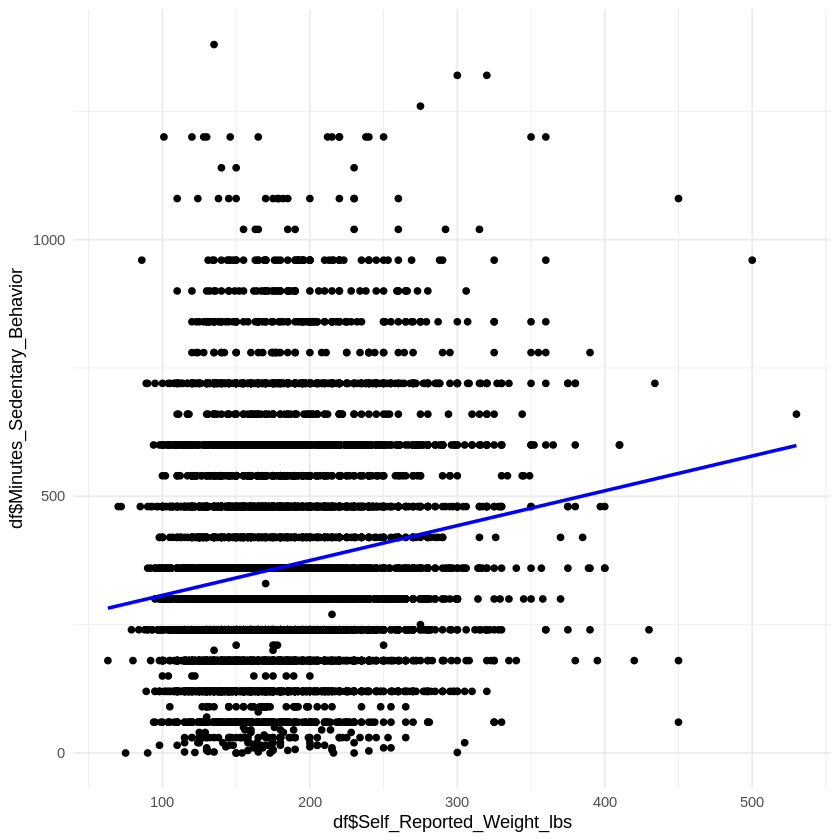

In [12]:
# Question 4: Is there a correlation between self reported weight and minutes of sedentary behavior? Regression

install.packages("lmtest")
library(ggplot2)
library(lmtest)

df = read.csv('/content/nhanes_adults_clean.csv')

model <- lm(df$Minutes_Sedentary_Behavior ~ df$Self_Reported_Weight_lbs)
summary(model)

ggplot(df, aes(x = df$Self_Reported_Weight_lbs, y = df$Minutes_Sedentary_Behavior)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  theme_minimal()

# Answer: Yes, there is a correlation. As self reported weight increases, minutes of sedentary behavior
# also increases

In [13]:
# Question 5: Is there an association between diabetes and weak or failing kidneys? Chi-square

contingency_table <- table(data$Diabetes, data$Weak.Failing_Kidneys)
chi2_test <- chisq.test(contingency_table)
print(chi2_test)

# Answer: The small p-value indicates there is an association that is statistically significant

Warning message in chisq.test(contingency_table):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  contingency_table
X-squared = 284.79, df = 4, p-value < 2.2e-16

